In [ ]:
!pip install inference_sdk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.11.0.86
    Uninstalling opencv-python-4.11.0.86:
      Successfully uninstalled opencv-python-4.11.0.86
  Attempting uninstall: aiohttp
    Found existing installation: aiohttp 3.11.15
    Uninstalling aiohttp-3.11.15:
      Successfully uninstalled aiohttp-3.11.15


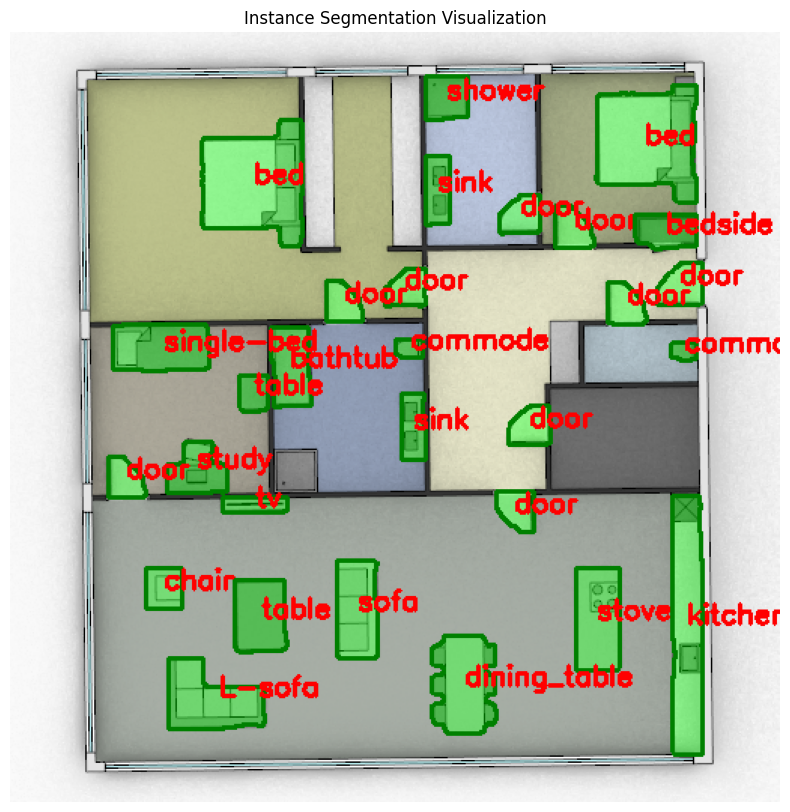

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from inference_sdk import InferenceHTTPClient

# Initialize Roboflow client
CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="bngHGPb2UJDgzZlQGaTu"
)

# Inference on image
result = CLIENT.infer("/content/flat_floorplan.png", model_id="furniture-ya4pe/1")

# Load and convert image
image = cv2.imread("/content/image1.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Draw polygons (instance segmentation masks)
for prediction in result['predictions']:
    if 'points' in prediction:
        pts = np.array([[int(p['x']), int(p['y'])] for p in prediction['points']], np.int32)
        pts = pts.reshape((-1, 1, 2))

        # Draw filled polygon (optional: use alpha blending for transparency)
        overlay = image.copy()
        color = (0, 255, 0)  # green for mask
        cv2.fillPoly(overlay, [pts], color)
        image = cv2.addWeighted(overlay, 0.4, image, 0.6, 0)

        # Optionally draw the outline
        cv2.polylines(image, [pts], isClosed=True, color=(0, 128, 0), thickness=2)

        # Add label
        if 'class' in prediction:
            label = prediction['class']
            cx = int(prediction['x'])
            cy = int(prediction['y'])
            cv2.putText(image, label, (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# Show result
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off')
plt.title("Instance Segmentation Visualization")
plt.show()

In [ ]:
result

{'inference_id': '5166f0ac-791c-40a9-acb2-b4a5c5c7003a',
 'time': 0.5387487890002376,
 'image': {'width': 513, 'height': 513},
 'predictions': [{'x': 276.0,
   'y': 114.5,
   'width': 48.0,
   'height': 53.0,
   'confidence': 0.9769685864448547,
   'class': 'stove',
   'points': [{'x': 266.9203186035156, 'y': 88.171875},
    {'x': 262.1109313964844, 'y': 92.98124694824219},
    {'x': 261.3093566894531, 'y': 92.98124694824219},
    {'x': 258.1031188964844, 'y': 96.1875},
    {'x': 257.3015441894531, 'y': 96.1875},
    {'x': 256.5, 'y': 96.98905944824219},
    {'x': 255.6984405517578, 'y': 96.98905944824219},
    {'x': 255.6984405517578, 'y': 97.7906265258789},
    {'x': 254.89686584472656, 'y': 98.5921859741211},
    {'x': 254.09530639648438, 'y': 98.5921859741211},
    {'x': 252.4921875, 'y': 100.1953125},
    {'x': 251.6906280517578, 'y': 100.1953125},
    {'x': 251.6906280517578, 'y': 100.99687194824219},
    {'x': 252.4921875, 'y': 101.7984390258789},
    {'x': 252.4921875, 'y': 103

In [ ]:
import os

In [ ]:
import cv2
import numpy as np
import os
from inference_sdk import InferenceHTTPClient

# Initialize Roboflow client
CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="bngHGPb2UJDgzZlQGaTu"
)

# Inference
img_path = "/content/flat_floorplan.png"
result = CLIENT.infer(img_path, model_id="furniture-ya4pe/1")

# Load image
image = cv2.imread(img_path)

# Output folder
output_dir = "/content/drive/MyDrive/furniture_crops"
os.makedirs(output_dir, exist_ok=True)

# Process each instance
for idx, prediction in enumerate(result['predictions']):
    if 'points' in prediction:
        # Create mask from polygon points
        polygon = np.array([[int(p['x']), int(p['y'])] for p in prediction['points']], np.int32)
        mask = np.zeros(image.shape[:2], dtype=np.uint8)
        cv2.fillPoly(mask, [polygon], 255)

        # Apply mask to image
        masked = cv2.bitwise_and(image, image, mask=mask)

        # Crop region of interest
        x, y, w, h = cv2.boundingRect(polygon)
        cropped_rgb = masked[y:y+h, x:x+w]
        cropped_mask = mask[y:y+h, x:x+w]

        # Create transparent image (RGBA)
        b, g, r = cv2.split(cropped_rgb)
        rgba = cv2.merge((b, g, r, cropped_mask))

        # Save clean crop with transparency
        class_name = prediction['class']
        filename = f"{idx}_{class_name}.png"
        cv2.imwrite(os.path.join(output_dir, filename), rgba)

print(f"✅ Saved clean furniture crops to: {output_dir}")


✅ Saved clean furniture crops to: /content/drive/MyDrive/furniture_crops


In [ ]:
import os
import cv2
import json

# Path to furniture crop directory
furniture_dir = "/content/drive/MyDrive/furniture_crops"
pixel_to_meter = 0.1

measurements = {}

print("📏 Furniture Measurements:\n")

for fname in os.listdir(furniture_dir):
    if fname.endswith(".png"):
        fpath = os.path.join(furniture_dir, fname)

        # Load image with alpha channel
        img = cv2.imread(fpath, cv2.IMREAD_UNCHANGED)
        if img is None or img.shape[2] != 4:
            continue

        alpha = img[:, :, 3]
        coords = cv2.findNonZero(alpha)
        if coords is None:
            continue

        x, y, w, h = cv2.boundingRect(coords)

        width_m = round(w * pixel_to_meter, 2)
        height_m = round(h * pixel_to_meter, 2)

        measurements[fname] = {
            "width_m": width_m,
            "height_m": height_m
        }

        # Print each furniture's dimensions
        print(f"{fname}: Width = {width_m} m, Height = {height_m} m")

# Save to JSON
save_path = os.path.join(furniture_dir, "furniture_measurements.json")
with open(save_path, 'w') as f:
    json.dump(measurements, f, indent=2)

print(f"\n✅ Saved all measurements to: {save_path}")


📏 Furniture Measurements:

0_sink.png: Width = 1.7 m, Height = 4.7 m
1_stove.png: Width = 3.0 m, Height = 6.9 m
2_bathtub.png: Width = 2.8 m, Height = 5.4 m
3_bed.png: Width = 6.8 m, Height = 7.9 m
4_sink.png: Width = 1.7 m, Height = 4.5 m
5_door.png: Width = 2.9 m, Height = 2.7 m
6_door.png: Width = 2.7 m, Height = 2.9 m
7_door.png: Width = 3.1 m, Height = 2.9 m
8_dining_table.png: Width = 4.4 m, Height = 6.6 m
9_shower.png: Width = 2.9 m, Height = 3.0 m
10_bed.png: Width = 6.8 m, Height = 8.5 m
11_door.png: Width = 2.7 m, Height = 2.9 m
12_tv.png: Width = 4.4 m, Height = 1.1 m
13_single-bed.png: Width = 6.5 m, Height = 3.2 m
14_bedside.png: Width = 4.2 m, Height = 2.4 m
15_door.png: Width = 2.8 m, Height = 2.7 m
16_commode.png: Width = 1.8 m, Height = 1.3 m
17_L-sofa.png: Width = 6.5 m, Height = 4.8 m
18_door.png: Width = 2.8 m, Height = 2.6 m
19_chair.png: Width = 2.5 m, Height = 2.8 m
20_door.png: Width = 2.5 m, Height = 2.8 m
21_study.png: Width = 4.1 m, Height = 3.5 m
22_table.pn